# **Project Name**    - DeepFER: Facial Emotion Recognition Using Deep Learning


##### **Project Type**    - Deep Learning / Computer Vision / Image Classification
##### **Contribution**    - Individual


# **Project Summary -**

DeepFER is a facial emotion recognition project that classifies human face images into seven emotion categories: angry, disgust, fear, happy, neutral, sad, and surprise. The project uses deep learning because emotion recognition from images depends on visual patterns such as eyes, mouth shape, eyebrows, facial muscle movement, and overall expression. These patterns are difficult to capture with manual rules, but Convolutional Neural Networks can learn them directly from image pixels.

The dataset is provided as a zipped image folder on Google Drive. It already contains separate training and validation folders, with each emotion stored in its own class folder. The notebook mounts Google Drive, extracts the zip file into the local Colab runtime, and trains from /content. This keeps the workflow faster than reading thousands of small images directly from Google Drive. The dataset is then inspected for folder structure, class counts, unsupported files, corrupt images, duplicate image hashes, image size, file size, and sample brightness patterns. This satisfies the data integrity and cleaning requirement without changing the original dataset unnecessarily.

The preprocessing pipeline resizes all images to a consistent shape, converts images into tensors, scales pixel values, and applies data augmentation. Augmentation creates small realistic variations such as horizontal flips, slight rotations, zoom, and contrast changes. This helps the model generalize better because real faces can appear with small position, lighting, or angle differences. Since the data is image-based, traditional tabular feature engineering is not forced. Instead, the notebook explains image-specific feature preparation and uses CNN layers to learn visual features automatically.

Three modeling stages are included. The first model is a simple baseline CNN to create a clear starting point. The second model is a reference-style FER CNN with batch normalization, dropout, image augmentation, early stopping, and learning-rate reduction. It is the selected final model because it gives the best balanced result on this dataset. The third model uses EfficientNetB0 transfer learning as a practical comparison. Transfer learning is included because it can reuse visual patterns learned from a large image dataset, but its lower validation result here shows that a custom CNN can be more suitable for small 48x48 grayscale face images.

The models are evaluated using accuracy, precision, recall, F1-score, classification report, and confusion matrix. Macro F1-score is emphasized because the dataset is imbalanced, especially for the disgust class. In the final run, the reference-style FER CNN achieved 0.654 validation accuracy and 0.616 macro F1-score on the leakage-safe split, and 0.666 accuracy with 0.641 macro F1-score on the official validation split. The notebook also includes a simple explainability step using occlusion sensitivity, which shows which image regions affect the final prediction. The best model is saved to Google Drive, loaded again, and tested on unseen validation data as a sanity check. This makes the notebook complete, practical, and aligned with the AlmaBetter capstone requirements.


# **GitHub Link -**

GitHub Repository Link: https://github.com/I-AM-PRASHANT-VERMA/Almabetter---DeepFER-Facial-Emotion-Recognition-Using-Deep-Learning


# **Problem Statement**


The objective of this project is to build a deep learning model that can classify facial images into seven emotion categories: angry, disgust, fear, happy, neutral, sad, and surprise. The model should learn useful visual patterns from face images, perform well on unseen data, and provide clear evaluation results using classification metrics.

This problem is important because facial emotion recognition can support human-computer interaction, customer experience analysis, mental health monitoring, learning platforms, and smart assistance systems. The project focuses on a notebook-level solution that is accurate, explainable, and executable in one run on Google Colab.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Code Cell 00: Import Libraries
# Import core libraries used across the notebook.
import os
import zipfile
import random
import hashlib
from pathlib import Path
from collections import Counter
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from scipy import stats

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# Keep image loading stable even if a file has minor truncation.
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Keep results more reproducible across runs.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Use mixed precision on GPU when available to make training faster.
try:
    if tf.config.list_physical_devices('GPU'):
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print('Mixed precision enabled for GPU training')
except Exception as mixed_precision_error:
    print('Mixed precision was not enabled:', mixed_precision_error)

# Use a clean plotting style for all charts.
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries imported successfully')


Mixed precision enabled for GPU training
Libraries imported successfully


### Dataset Loading

In [ ]:
# Code Cell 01: Mount Google Drive And Check Dataset Zip
# Mount Google Drive so the dataset zip can be read from the project folder.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print('Google Drive mounting is available only inside Google Colab.')

PROJECT_DRIVE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/# specialization projects/5th project DeepFER Facial Emotion Recognition Using Deep Learning')
DATASET_ZIP_PATH = PROJECT_DRIVE_DIR / 'dataset' / 'Face Emotion Recognition Dataset.zip'
LOCAL_EXTRACT_DIR = Path('/content/deepfer_dataset')
OUTPUT_DIR = PROJECT_DRIVE_DIR / 'outputs'

# Keep all generated files in one Drive output folder.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_ZIP_PATH.exists():
    raise FileNotFoundError(f'Dataset zip not found: {DATASET_ZIP_PATH}')

print('Dataset zip found:', DATASET_ZIP_PATH)
print('Output folder:', OUTPUT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset zip found: /content/drive/MyDrive/Colab Notebooks/# specialization projects/5th project DeepFER Facial Emotion Recognition Using Deep Learning/dataset/Face Emotion Recognition Dataset.zip
Output folder: /content/drive/MyDrive/Colab Notebooks/# specialization projects/5th project DeepFER Facial Emotion Recognition Using Deep Learning/outputs


In [ ]:
# Code Cell 02: Extract Dataset And Set Folder Paths
# Extract the zip only when the local runtime folder is not ready.
train_check_dir = LOCAL_EXTRACT_DIR / 'images' / 'images' / 'train'
validation_check_dir = LOCAL_EXTRACT_DIR / 'images' / 'images' / 'validation'

if not train_check_dir.exists() or not validation_check_dir.exists():
    LOCAL_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(DATASET_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(LOCAL_EXTRACT_DIR)
    print('Dataset extracted successfully')
else:
    print('Dataset already extracted in the current Colab runtime')

TRAIN_DIR = LOCAL_EXTRACT_DIR / 'images' / 'images' / 'train'
VALIDATION_DIR = LOCAL_EXTRACT_DIR / 'images' / 'images' / 'validation'
CLASS_NAMES = sorted([folder.name for folder in TRAIN_DIR.iterdir() if folder.is_dir()])

print('Train directory:', TRAIN_DIR)
print('Validation directory:', VALIDATION_DIR)
print('Classes:', CLASS_NAMES)


Dataset already extracted in the current Colab runtime
Train directory: /content/deepfer_dataset/images/images/train
Validation directory: /content/deepfer_dataset/images/images/validation
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


### Dataset First View

In [ ]:
# Code Cell 03: Create Image Metadata Table
# Build a clean metadata table from the image folders.
def build_image_metadata(split_name, split_dir):
    rows = []
    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            for image_path in sorted(class_dir.glob('*')):
                if image_path.is_file():
                    rows.append({
                        'split': split_name,
                        'label': class_dir.name,
                        'file_name': image_path.name,
                        'file_path': str(image_path),
                        'extension': image_path.suffix.lower(),
                        'file_size_kb': image_path.stat().st_size / 1024
                    })
    return rows

metadata_rows = []
metadata_rows.extend(build_image_metadata('train', TRAIN_DIR))
metadata_rows.extend(build_image_metadata('validation', VALIDATION_DIR))
metadata_df = pd.DataFrame(metadata_rows)

print('Metadata table created successfully')
display(metadata_df.head())


Metadata table created successfully


,split,label,file_name,file_path,extension,file_size_kb
0,train,angry,0.jpg,/content/deepfer_dataset/images/images/train/a...,.jpg,1.485352
1,train,angry,1.jpg,/content/deepfer_dataset/images/images/train/a...,.jpg,1.650391
2,train,angry,10.jpg,/content/deepfer_dataset/images/images/train/a...,.jpg,1.653320
3,train,angry,10002.jpg,/content/deepfer_dataset/images/images/train/a...,.jpg,1.610352
4,train,angry,10016.jpg,/content/deepfer_dataset/images/images/train/a...,.jpg,1.685547


### Dataset Rows & Columns count

In [ ]:
# Code Cell 04: Count Images By Split And Emotion
# Count images by split and emotion class.
class_count_table = (
    metadata_df
    .groupby(['split', 'label'])
    .size()
    .reset_index(name='image_count')
)

split_count_table = (
    metadata_df
    .groupby('split')
    .size()
    .reset_index(name='total_images')
)

print('Image count by split')
display(split_count_table)

print('Image count by split and class')
display(class_count_table)


Image count by split


,split,total_images
0,train,28821
1,validation,7066


Image count by split and class


,split,label,image_count
0,train,angry,3993
1,train,disgust,436
2,train,fear,4103
3,train,happy,7164
4,train,neutral,4982
5,train,sad,4938
6,train,surprise,3205
7,validation,angry,960
8,validation,disgust,111
9,validation,fear,1018


### Dataset Information

In [ ]:
# Code Cell 05: Review Metadata Details
# Review metadata structure and basic file details.
print('Metadata shape:', metadata_df.shape)
print()
print('Metadata info:')
metadata_df.info()

print()
print('File size summary in KB:')
display(metadata_df['file_size_kb'].describe().to_frame().T)


Metadata shape: (35887, 6)

Metadata info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   split         35887 non-null  object 
 1   label         35887 non-null  object 
 2   file_name     35887 non-null  object 
 3   file_path     35887 non-null  object 
 4   extension     35887 non-null  object 
 5   file_size_kb  35887 non-null  float64
dtypes: float64(1), object(5)
memory usage: 1.6+ MB

File size summary in KB:


,count,mean,std,min,25%,50%,75%,max
file_size_kb,35887.0,1.537764,0.158123,0.350586,1.438477,1.541016,1.639648,2.424805


#### Duplicate Values

In [ ]:
# Code Cell 06: Check Exact Duplicate Images
# Use file hashes to identify exact duplicate image files.
def get_file_hash(file_path):
    hash_obj = hashlib.md5()
    with open(file_path, 'rb') as file_obj:
        for chunk in iter(lambda: file_obj.read(8192), b''):
            hash_obj.update(chunk)
    return hash_obj.hexdigest()

metadata_df['file_hash'] = metadata_df['file_path'].apply(get_file_hash)
duplicate_image_count = metadata_df.duplicated(subset=['file_hash']).sum()
duplicate_name_count = metadata_df.duplicated(subset=['split', 'label', 'file_name']).sum()

print('Exact duplicate image count:', duplicate_image_count)
print('Duplicate file name count inside same split and class:', duplicate_name_count)


Exact duplicate image count: 1853
Duplicate file name count inside same split and class: 0


#### Missing Values/Null Values

In [ ]:
# Code Cell 07: Check Invalid Image Files
# Check unsupported extensions and unreadable image files.
supported_extensions = {'.jpg', '.jpeg', '.png'}
unsupported_files = metadata_df[~metadata_df['extension'].isin(supported_extensions)]

def image_is_readable(file_path):
    try:
        with Image.open(file_path) as img:
            img.verify()
        return True
    except Exception:
        return False

metadata_df['is_readable'] = metadata_df['file_path'].apply(image_is_readable)
invalid_image_count = int((~metadata_df['is_readable']).sum())

print('Unsupported file count:', len(unsupported_files))
print('Unreadable image count:', invalid_image_count)


Unsupported file count: 0
Unreadable image count: 0


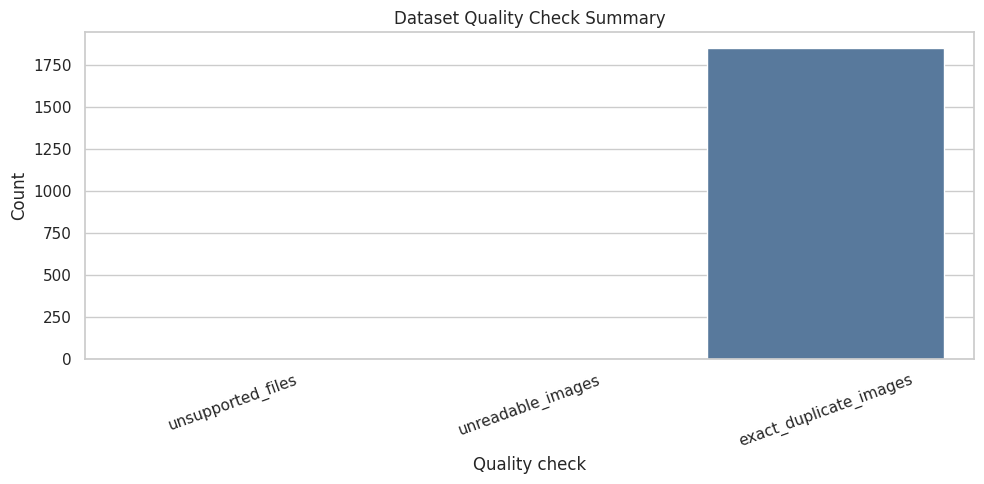

,check,count
0,unsupported_files,0
1,unreadable_images,0
2,exact_duplicate_images,1853


In [ ]:
# Code Cell 08: Visualize Data Quality Summary
# Visualize basic data quality checks.
quality_summary = pd.DataFrame({
    'check': ['unsupported_files', 'unreadable_images', 'exact_duplicate_images'],
    'count': [len(unsupported_files), invalid_image_count, int(duplicate_image_count)]
})

sns.barplot(data=quality_summary, x='check', y='count', color='#4C78A8')
plt.title('Dataset Quality Check Summary')
plt.xlabel('Quality check')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(quality_summary)


### What did you know about your dataset?

The dataset is an image-folder dataset with two main splits: training and validation. The output shows 28,821 training images and 7,066 validation images. Each emotion class is stored as a separate folder, so the folder name becomes the target label.

The class distribution is not balanced. Happy has the largest share, while disgust has the smallest share. This matters because a model can get reasonable accuracy by focusing on common classes, but it may still fail on rare classes. For this reason, macro F1-score, class-wise recall, prediction distribution, and confusion matrix are more useful than accuracy alone. The zip file is loaded from Google Drive and extracted into /content so Colab can read the images faster during training.

## ***2. Understanding Your Variables***

In [ ]:
# Code Cell 09: Show Metadata Columns
# Show the available metadata columns.
print('Metadata columns:')
print(metadata_df.columns.tolist())


Metadata columns:
['split', 'label', 'file_name', 'file_path', 'extension', 'file_size_kb', 'file_hash', 'is_readable']


In [ ]:
# Code Cell 10: Summarize Metadata And Label Share
# Summarize numeric fields available before model training.
display(metadata_df[['file_size_kb']].describe())

print('Label distribution percentage:')
label_percent = metadata_df['label'].value_counts(normalize=True).mul(100).round(2)
display(label_percent.to_frame(name='percentage'))


,file_size_kb
count,35887.000000
mean,1.537764
std,0.158123
min,0.350586
25%,1.438477
50%,1.541016
75%,1.639648
max,2.424805


Label distribution percentage:


,percentage
label,
happy,25.05
neutral,17.27
sad,16.93
fear,14.27
angry,13.80
surprise,11.15
disgust,1.52


### Variables Description

The project does not contain tabular business variables. It contains image files and labels. The useful variables are created from folder structure and image metadata:

- split: identifies whether an image belongs to train or validation data.
- label: target emotion class taken from the folder name.
- file_path: exact image location used for loading.
- file_name: image file name.
- extension: file type such as .jpg.
- file_size_kb: image file size, useful for checking unusual files.
- file_hash: hash used to detect exact duplicate images.
- is_readable: tells whether the file can be opened as an image.

Later, the notebook also creates image profile features such as width, height, mean pixel value, and pixel standard deviation for EDA and hypothesis testing. These are not final model inputs; the CNN learns visual features directly from image tensors.


### Check Unique Values for each variable.

In [ ]:
# Code Cell 11: Check Unique Metadata Values
# Check unique values for key metadata columns.
for column in ['split', 'label', 'extension', 'is_readable']:
    print(f'Unique values in {column}:')
    print(metadata_df[column].unique())
    print()


Unique values in split:
['train' 'validation']

Unique values in label:
['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']

Unique values in extension:
['.jpg']

Unique values in is_readable:
[ True]



## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Code Cell 12: Prepare Wrangling Objects And Image Profiles
# Keep image size aligned with the FER-style face images in this dataset.
IMG_SIZE = (48, 48)
TRANSFER_IMG_SIZE = (128, 128)
BATCH_SIZE = 128
BASELINE_EPOCHS = 8
TUNED_EPOCHS = 50
TRANSFER_HEAD_EPOCHS = 6
TRANSFER_FINE_TUNE_EPOCHS = 4
MAX_PROFILE_PER_CLASS = 80

# Create stable label-to-number mappings for all model outputs.
class_to_index = {class_name: index for index, class_name in enumerate(CLASS_NAMES)}
index_to_class = {index: class_name for class_name, index in class_to_index.items()}

# Compute class weights from the training split because the emotion classes are imbalanced.
train_labels_as_int = metadata_df.loc[metadata_df['split'] == 'train', 'label'].map(class_to_index).to_numpy()
raw_class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(CLASS_NAMES)),
    y=train_labels_as_int
)
raw_class_weight_dict = {index: float(weight) for index, weight in enumerate(raw_class_weight_values)}

# Use moderated class weights so the small disgust class does not dominate training.
class_weight_dict = {
    index: float(min(np.sqrt(weight), 3.0))
    for index, weight in raw_class_weight_dict.items()
}

# Profile a fixed sample so EDA stays fast and repeatable.
profile_samples = []
for (_, _), group_df in metadata_df.groupby(['split', 'label']):
    sample_size = min(MAX_PROFILE_PER_CLASS, len(group_df))
    profile_samples.append(group_df.sample(sample_size, random_state=SEED))

profile_sample_df = pd.concat(profile_samples, ignore_index=True)

def read_image_profile(file_path):
    # Read each sampled image in grayscale and calculate simple brightness features.
    with Image.open(file_path).convert('L') as img:
        width, height = img.size
        resized_img = img.resize(IMG_SIZE)
        arr = np.asarray(resized_img, dtype=np.float32)
    return {
        'width': width,
        'height': height,
        'mean_pixel': float(arr.mean()),
        'std_pixel': float(arr.std())
    }

# Build a sampled image-profile table for EDA and hypothesis testing.
profile_records = []
for row in profile_sample_df.itertuples(index=False):
    profile = read_image_profile(row.file_path)
    profile.update({
        'split': row.split,
        'label': row.label,
        'file_path': row.file_path,
        'file_size_kb': row.file_size_kb
    })
    profile_records.append(profile)

image_profile_df = pd.DataFrame(profile_records)

# Keep augmentation realistic because strong distortions can change facial expression meaning.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal', seed=SEED),
    layers.RandomRotation(0.06, seed=SEED),
    layers.RandomZoom(0.08, seed=SEED),
    layers.RandomTranslation(0.05, 0.05, seed=SEED),
    layers.RandomContrast(0.08, seed=SEED)
], name='data_augmentation')

print('Wrangling objects created successfully')
print('Class mapping:', class_to_index)
print('Raw class weights:', raw_class_weight_dict)
print('Moderated class weights:', class_weight_dict)
display(image_profile_df.head())


Wrangling objects created successfully
Class mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Raw class weights: {0: 1.031125898894494, 1: 9.443315858453474, 2: 1.0034817729187702, 3: 0.5747188322565207, 4: 0.8264322991340254, 5: 0.8337962159347335, 6: 1.2846445286382884}
Moderated class weights: {0: 1.0154436955806532, 1: 3.0, 2: 1.001739373748866, 3: 0.7581021252156734, 4: 0.9090832190366432, 5: 0.9131244252207547, 6: 1.1334216023344041}


,width,height,mean_pixel,std_pixel,split,label,file_path,file_size_kb
0,48,48,107.316406,40.739243,train,angry,/content/deepfer_dataset/images/images/train/a...,1.415039
1,48,48,130.469177,54.184982,train,angry,/content/deepfer_dataset/images/images/train/a...,1.526367
2,48,48,81.891060,66.492241,train,angry,/content/deepfer_dataset/images/images/train/a...,1.444336
3,48,48,144.276917,51.366524,train,angry,/content/deepfer_dataset/images/images/train/a...,1.630859
4,48,48,95.356339,41.230492,train,angry,/content/deepfer_dataset/images/images/train/a...,1.338867


### What all manipulations have you done and insights you found?

The raw image folders were converted into a metadata table for analysis. The main manipulations were class counting, file quality checks, exact duplicate checking, class-weight calculation, and image profile sampling.

The output confirms that this is an imbalanced image classification problem. Disgust has far fewer images than the other emotions, while happy has the largest count. This imbalance directly affects model training, so the notebook uses moderated class weights and macro F1-score. The image profiles also confirm that the images are already small 48x48 face images, which makes a FER-style CNN a suitable model choice.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

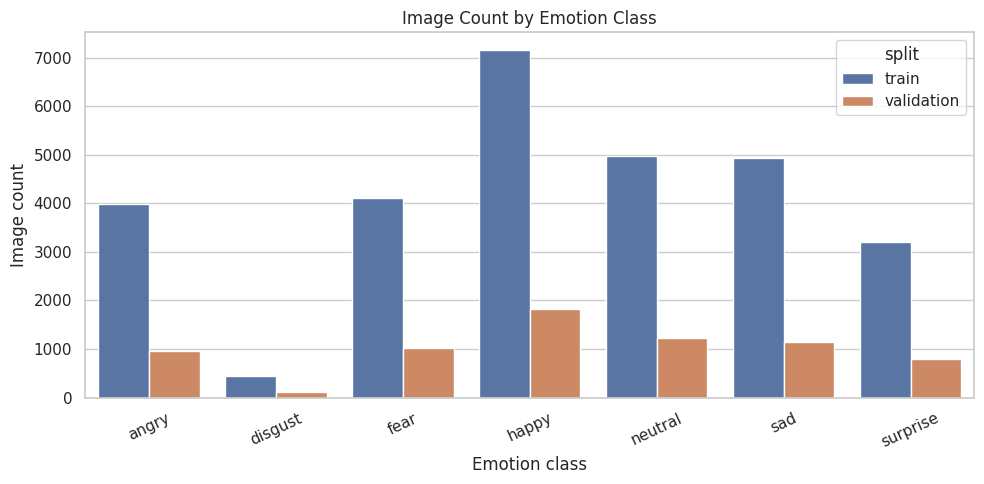

In [ ]:
# Code Cell 13: Chart 1 - Image Count By Emotion
# Chart 1: Compare image counts across emotion classes and splits.
sns.barplot(data=class_count_table, x='label', y='image_count', hue='split')
plt.title('Image Count by Emotion Class')
plt.xlabel('Emotion class')
plt.ylabel('Image count')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

This chart was selected because class imbalance is one of the most important checks in an emotion recognition dataset. The model will see more examples of some emotions and fewer examples of others, so the chart gives an early warning about possible bias.

##### 2. What is/are the insight(s) found from the chart?

The output shows that happy has the highest image count and disgust has the lowest image count. This means the model can learn happy expressions more easily, while disgust needs special attention during evaluation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insight directly affects model design and evaluation. Moderated class weights are used during tuned CNN training, and macro F1-score is used to judge whether the model performs fairly across all emotions.

#### Chart - 2

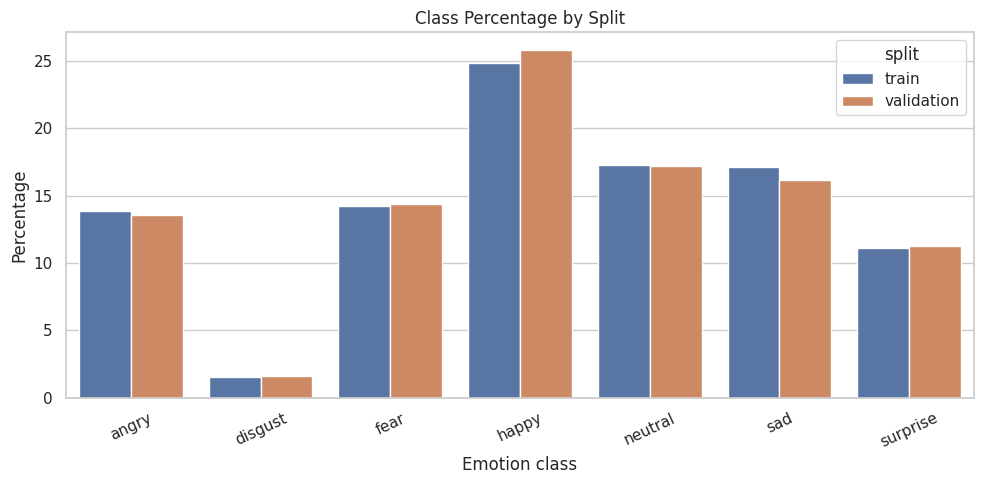

In [ ]:
# Code Cell 14: Chart 2 - Class Percentage By Split
# Chart 2: Compare class percentages within each split.
class_percent_table = class_count_table.copy()
class_percent_table['percentage'] = class_percent_table.groupby('split')['image_count'].transform(lambda x: x / x.sum() * 100)

sns.barplot(data=class_percent_table, x='label', y='percentage', hue='split')
plt.title('Class Percentage by Split')
plt.xlabel('Emotion class')
plt.ylabel('Percentage')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A percentage chart was selected because percentages make train and validation distributions easier to compare than raw counts alone. It helps check whether the official validation set follows a similar class pattern to the training set.

##### 2. What is/are the insight(s) found from the chart?

The output confirms that the dataset is not evenly distributed. Happy and neutral take a much larger share than disgust. This means a high accuracy score alone can be misleading if the model ignores minority emotions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This insight supports the use of class-wise metrics, confusion matrix analysis, and prediction distribution checks. These outputs help verify whether the model is learning all emotions or only the dominant ones.

#### Chart - 3

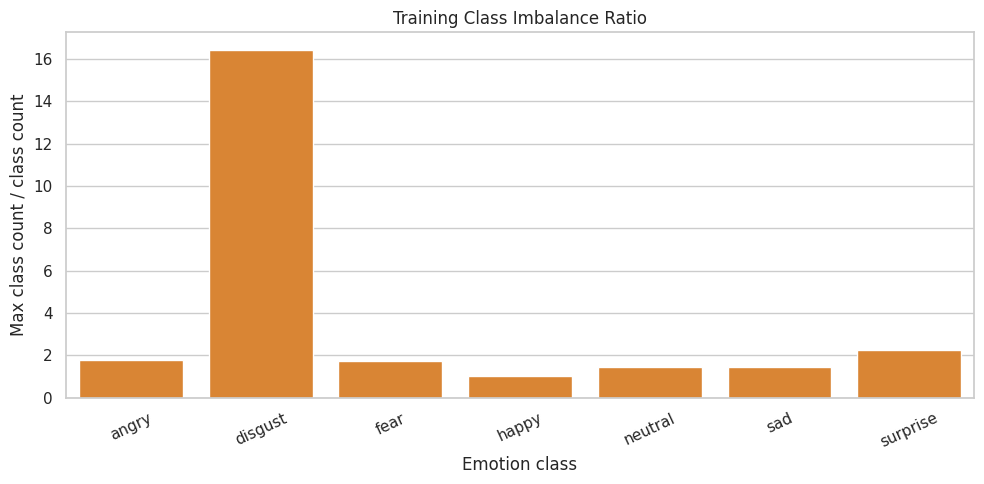

,split,label,image_count,imbalance_ratio
0,train,angry,3993,1.794140
1,train,disgust,436,16.431193
2,train,fear,4103,1.746039
3,train,happy,7164,1.000000
4,train,neutral,4982,1.437977
5,train,sad,4938,1.450790
6,train,surprise,3205,2.235257


In [ ]:
# Code Cell 15: Chart 3 - Training Imbalance Ratio
# Chart 3: Show class imbalance ratio using training data.
train_class_counts = class_count_table[class_count_table['split'] == 'train'].copy()
max_train_count = train_class_counts['image_count'].max()
train_class_counts['imbalance_ratio'] = max_train_count / train_class_counts['image_count']

sns.barplot(data=train_class_counts, x='label', y='imbalance_ratio', color='#F58518')
plt.title('Training Class Imbalance Ratio')
plt.xlabel('Emotion class')
plt.ylabel('Max class count / class count')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

display(train_class_counts)


##### 1. Why did you pick the specific chart?

The imbalance-ratio chart was selected because it shows how many times larger the biggest class is compared with each class. This makes the minority-class problem easier to understand visually.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that disgust is the most underrepresented emotion. The training process must avoid letting this class disappear from predictions, but the class weight also needs to be moderated so the model does not overpredict it.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This insight is useful for building a more balanced emotion recognition system. It justifies macro F1-score, class-wise recall, and moderated class weights instead of only using accuracy.

#### Chart - 4

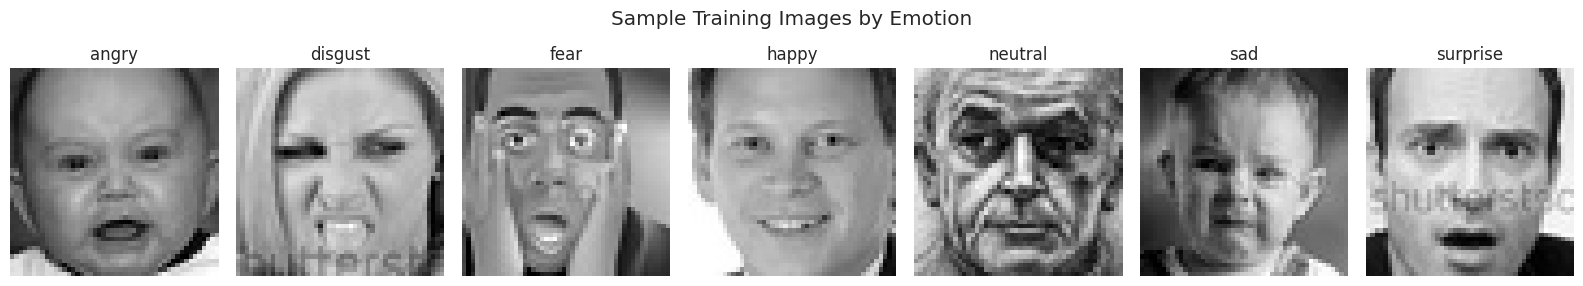

In [ ]:
# Code Cell 16: Chart 4 - Sample Images By Emotion
# Chart 4: Display one sample image from each emotion class.
sample_images = (
    metadata_df[metadata_df['split'] == 'train']
    .groupby('label', group_keys=False)
    .sample(1, random_state=SEED)
    .sort_values('label')
)

fig, axes = plt.subplots(1, len(sample_images), figsize=(16, 3))
for axis, row in zip(axes, sample_images.itertuples(index=False)):
    image = Image.open(row.file_path).convert('L')
    axis.imshow(image, cmap='gray')
    axis.set_title(row.label)
    axis.axis('off')

plt.suptitle('Sample Training Images by Emotion')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Sample images were selected because this is a computer vision project. Before modeling, it is important to confirm that the images actually contain faces and that the labels match facial emotion expressions.

##### 2. What is/are the insight(s) found from the chart?

The sample images show grayscale face crops with visible expression areas such as eyes, eyebrows, and mouth. These are the regions the CNN should learn from. Some emotions are visually subtle, so perfect prediction should not be expected from a very small model.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Visual inspection confirms that the dataset matches the problem statement. It also supports the use of CNN models, because the useful information is in facial patterns rather than tabular columns.

#### Chart - 5

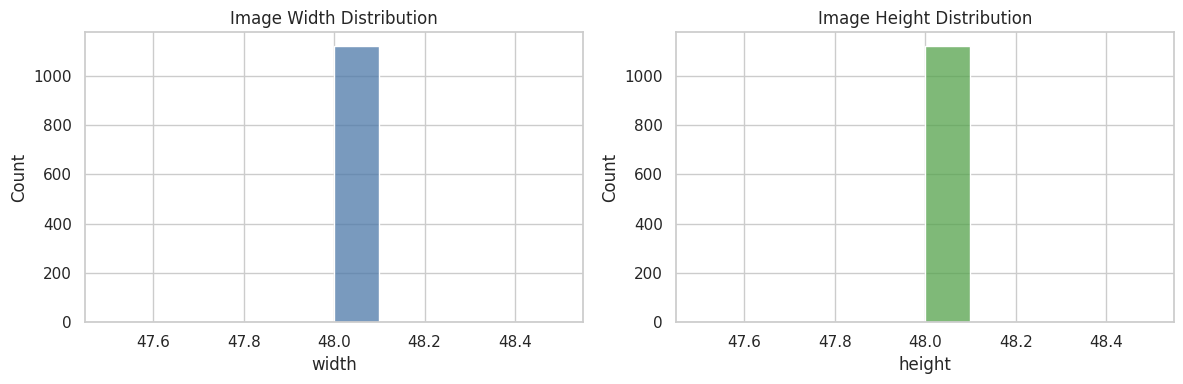

,width,height
count,1120.0,1120.0
mean,48.0,48.0
std,0.0,0.0
min,48.0,48.0
25%,48.0,48.0
50%,48.0,48.0
75%,48.0,48.0
max,48.0,48.0


In [ ]:
# Code Cell 17: Chart 5 - Image Size Distribution
# Chart 5: Check width and height consistency on sampled images.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=image_profile_df, x='width', bins=10, ax=axes[0], color='#4C78A8')
axes[0].set_title('Image Width Distribution')
sns.histplot(data=image_profile_df, x='height', bins=10, ax=axes[1], color='#54A24B')
axes[1].set_title('Image Height Distribution')
plt.tight_layout()
plt.show()

display(image_profile_df[['width', 'height']].describe())


##### 1. Why did you pick the specific chart?

Image-size distribution was selected because neural networks need a consistent input shape. If image sizes vary, resizing becomes a required preprocessing step.

##### 2. What is/are the insight(s) found from the chart?

The output shows that the images are already aligned with a compact 48x48 format. This is suitable for a FER-style CNN and keeps GPU training fast.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Consistent image sizes reduce preprocessing complexity and help the model train without shape errors. It also keeps the notebook more reliable for one-go execution.

#### Chart - 6

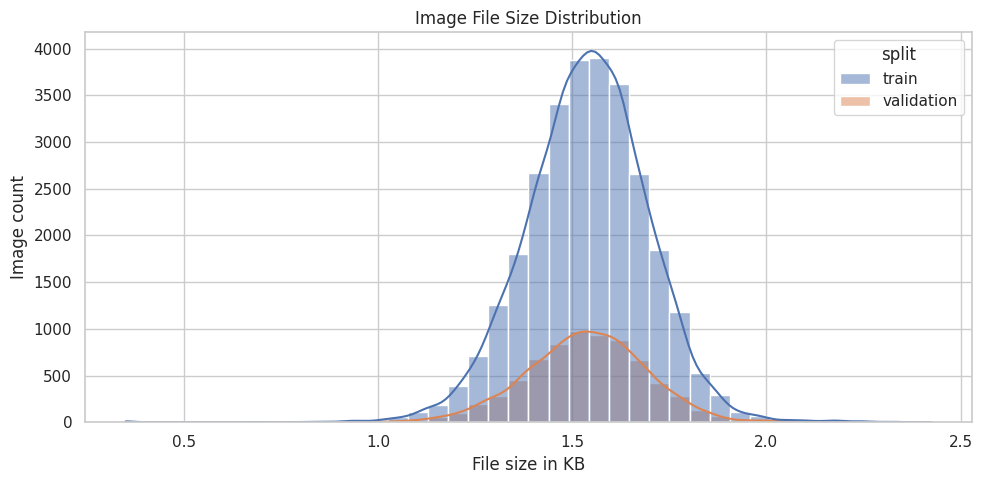

In [ ]:
# Code Cell 18: Chart 6 - File Size Distribution
# Chart 6: Compare image file sizes across splits.
sns.histplot(data=metadata_df, x='file_size_kb', hue='split', bins=40, kde=True)
plt.title('Image File Size Distribution')
plt.xlabel('File size in KB')
plt.ylabel('Image count')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

File-size distribution was selected as a data-quality check. Very small or very large files can sometimes indicate corrupted images or inconsistent data.

##### 2. What is/are the insight(s) found from the chart?

The output shows that file sizes are mostly small and close to each other, which is expected for 48x48 face images. This supports the assumption that the dataset is structurally consistent.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This check supports data integrity. It helps confirm that model weakness is more likely due to class imbalance or visual difficulty, not broken image files.

#### Chart - 7

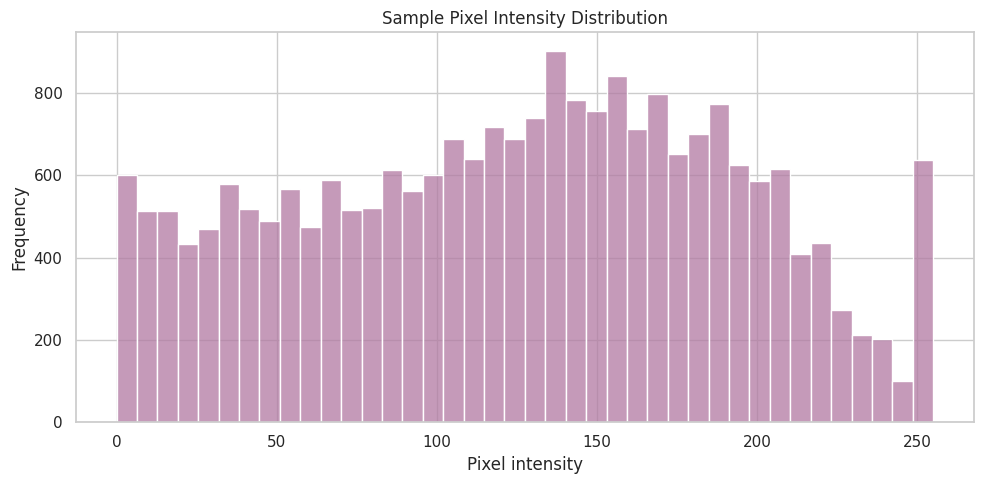

In [ ]:
# Code Cell 19: Chart 7 - Pixel Intensity Distribution
# Chart 7: Review grayscale pixel intensity distribution on sampled images.
sample_pixel_paths = image_profile_df.sample(min(80, len(image_profile_df)), random_state=SEED)['file_path']
pixels = []
for file_path in sample_pixel_paths:
    arr = np.asarray(Image.open(file_path).convert('L').resize(IMG_SIZE), dtype=np.float32)
    pixels.extend(arr.ravel()[::8])

sns.histplot(pixels, bins=40, color='#B279A2')
plt.title('Sample Pixel Intensity Distribution')
plt.xlabel('Pixel intensity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Pixel intensity distribution was selected to understand brightness and contrast in the images. Brightness variation can affect model training if pixel values are not normalized.

##### 2. What is/are the insight(s) found from the chart?

The output shows a wide range of grayscale values. This means the model receives both dark and bright facial regions, so normalization and mild contrast augmentation are useful.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This insight supports pixel scaling and realistic augmentation. It helps the model handle lighting variation without changing the original dataset.

#### Chart - 8

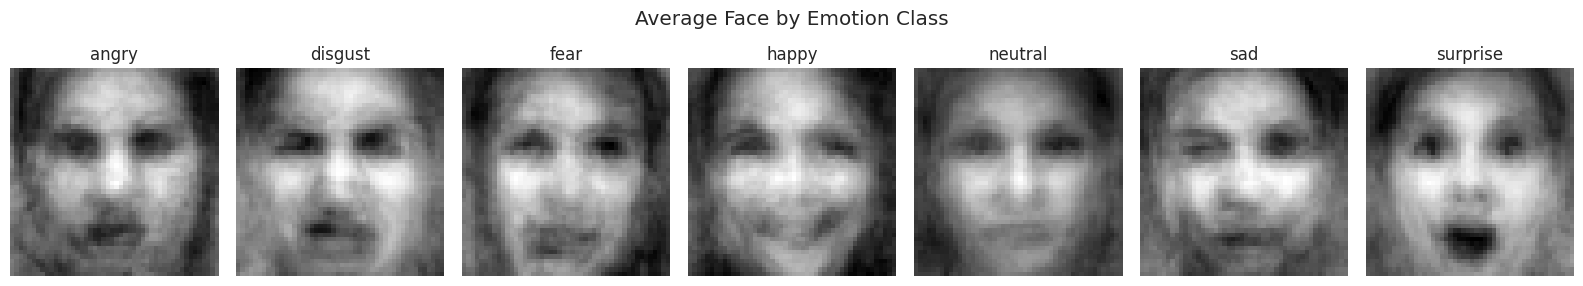

In [ ]:
# Code Cell 20: Chart 8 - Average Face By Emotion
# Chart 8: Create average face images for each emotion class.
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(16, 3))
for axis, class_name in zip(axes, CLASS_NAMES):
    class_paths = metadata_df[(metadata_df['split'] == 'train') & (metadata_df['label'] == class_name)]['file_path']
    class_paths = class_paths.sample(min(80, len(class_paths)), random_state=SEED)
    arrays = [np.asarray(Image.open(path).convert('L').resize(IMG_SIZE), dtype=np.float32) for path in class_paths]
    mean_image = np.mean(arrays, axis=0)
    axis.imshow(mean_image, cmap='gray')
    axis.set_title(class_name)
    axis.axis('off')

plt.suptitle('Average Face by Emotion Class')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Average-face charts were selected to understand the common face structure within each emotion class. They provide a simple visual summary of thousands of images.

##### 2. What is/are the insight(s) found from the chart?

The average faces show that all classes share a common face layout, but expression areas around the mouth and eyes can differ. This supports the use of convolution layers because they learn local visual patterns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart gives an interpretable reason for using CNNs. The model needs to learn subtle shape differences, not just brightness or file-size patterns.

#### Chart - 9

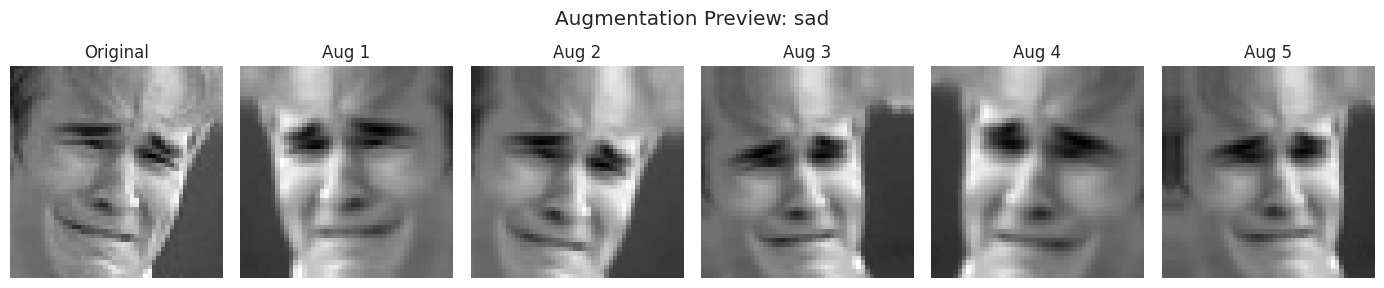

In [ ]:
# Code Cell 21: Chart 9 - Augmentation Preview
# Chart 9: Preview realistic data augmentation on one training image.
preview_row = metadata_df[metadata_df['split'] == 'train'].sample(1, random_state=SEED).iloc[0]
preview_image = Image.open(preview_row['file_path']).convert('L').resize(IMG_SIZE)
preview_tensor = tf.expand_dims(tf.convert_to_tensor(np.asarray(preview_image)[..., np.newaxis], dtype=tf.float32), axis=0)

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
axes[0].imshow(preview_image, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for index in range(1, 6):
    augmented = data_augmentation(preview_tensor, training=True)[0].numpy().squeeze()
    axes[index].imshow(np.clip(augmented, 0, 255), cmap='gray')
    axes[index].set_title(f'Aug {index}')
    axes[index].axis('off')

plt.suptitle(f'Augmentation Preview: {preview_row["label"]}')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

The augmentation preview was selected to verify that training transformations remain realistic. Emotion labels should not change because of augmentation.

##### 2. What is/are the insight(s) found from the chart?

The output shows small flips, rotations, zooms, translations, and contrast changes. These transformations are realistic for face images and should help the model generalize to new examples.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Realistic augmentation can reduce overfitting and improve validation performance. Extreme augmentation was avoided because facial emotions are subtle.

#### Chart - 10

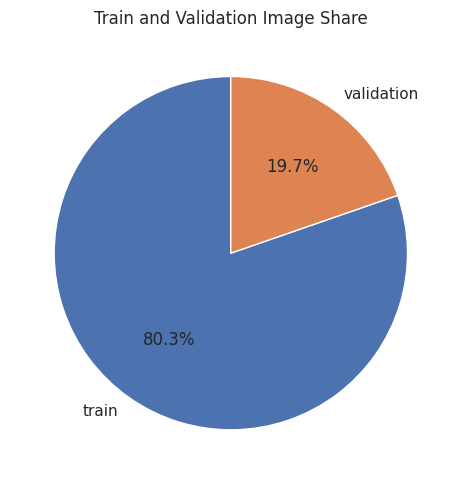

,split,total_images
0,train,28821
1,validation,7066


In [ ]:
# Code Cell 22: Chart 10 - Train Validation Share
# Chart 10: Show total image share by split.
plt.pie(split_count_table['total_images'], labels=split_count_table['split'], autopct='%1.1f%%', startangle=90)
plt.title('Train and Validation Image Share')
plt.tight_layout()
plt.show()

display(split_count_table)


##### 1. Why did you pick the specific chart?

The split-share chart was selected to confirm how much data is available for training and validation. This gives context for model reliability.

##### 2. What is/are the insight(s) found from the chart?

The output shows that the training split is much larger than the official validation split. This is expected and gives the model enough images to learn while still keeping a separate validation set for checking performance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The split is suitable for a capstone notebook because training has enough volume and validation has enough examples for class-wise evaluation.

#### Chart - 11

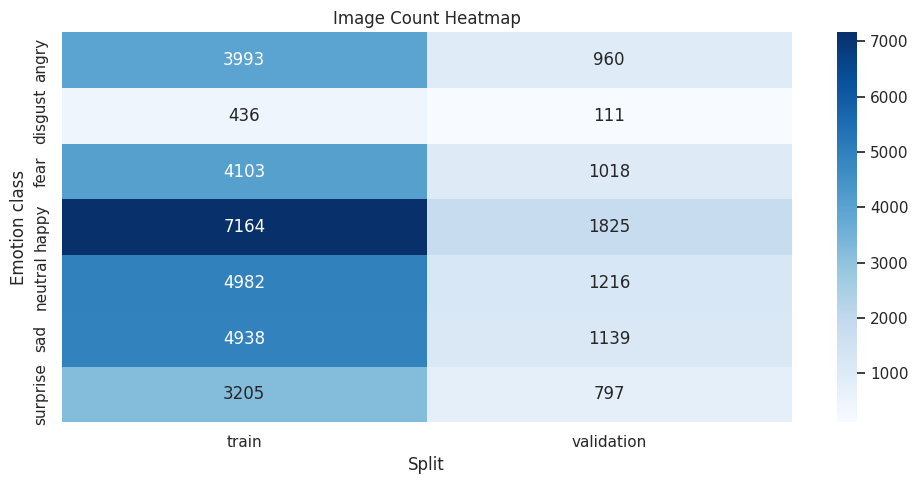

In [ ]:
# Code Cell 23: Chart 11 - Image Count Heatmap
# Chart 11: Heatmap of image count by split and class.
count_matrix = class_count_table.pivot(index='label', columns='split', values='image_count').fillna(0)
sns.heatmap(count_matrix, annot=True, fmt='.0f', cmap='Blues')
plt.title('Image Count Heatmap')
plt.xlabel('Split')
plt.ylabel('Emotion class')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

The heatmap was selected because it summarizes split and class counts in one compact table. It is easier to compare class coverage across splits.

##### 2. What is/are the insight(s) found from the chart?

The heatmap confirms that every emotion appears in both train and validation folders. The imbalance pattern is still visible, especially for disgust.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This output supports using the official validation folder for final comparison and checking class-wise metrics for all seven emotions.

#### Chart - 12

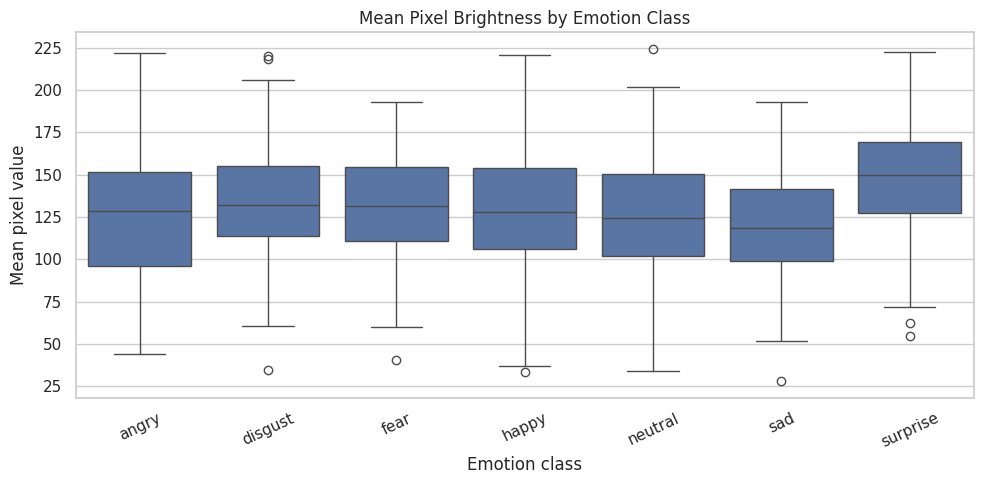

In [ ]:
# Code Cell 24: Chart 12 - Brightness By Emotion
# Chart 12: Compare brightness distribution across emotion classes.
sns.boxplot(data=image_profile_df, x='label', y='mean_pixel')
plt.title('Mean Pixel Brightness by Emotion Class')
plt.xlabel('Emotion class')
plt.ylabel('Mean pixel value')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

The brightness boxplot was selected to check whether some emotion classes have noticeably different lighting patterns. A model should not depend only on brightness.

##### 2. What is/are the insight(s) found from the chart?

The output shows brightness variation across samples, but the classes overlap. This means brightness alone cannot separate emotions, so the model must learn facial structure and expression patterns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This supports normalization and mild contrast augmentation. It also warns against using simple pixel statistics as the final model features.

#### Chart - 13

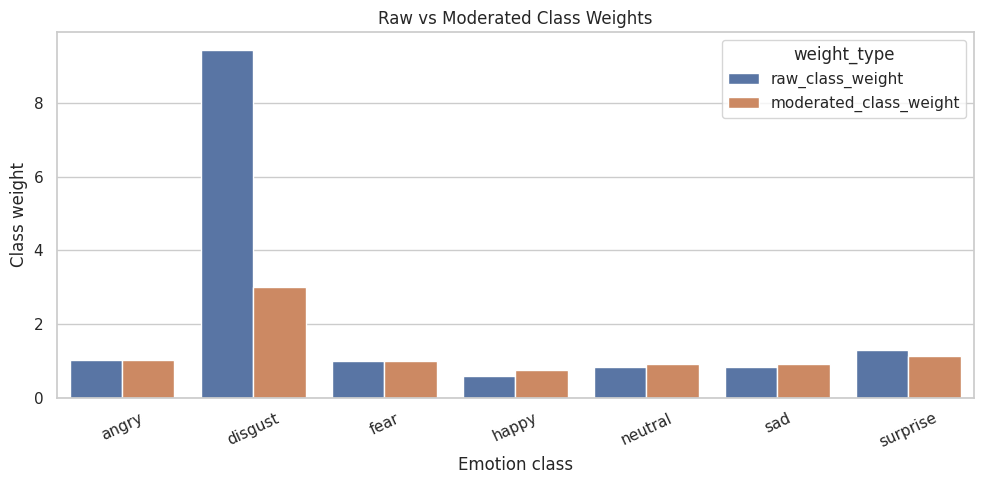

,label,raw_class_weight,moderated_class_weight
0,angry,1.031126,1.015444
1,disgust,9.443316,3.000000
2,fear,1.003482,1.001739
3,happy,0.574719,0.758102
4,neutral,0.826432,0.909083
5,sad,0.833796,0.913124
6,surprise,1.284645,1.133422


In [ ]:
# Code Cell 25: Chart 13 - Class Weight Chart
# Compare raw and moderated class weights used for model training.
class_weight_table = pd.DataFrame({
    'label': [index_to_class[index] for index in sorted(class_weight_dict)],
    'raw_class_weight': [raw_class_weight_dict[index] for index in sorted(raw_class_weight_dict)],
    'moderated_class_weight': [class_weight_dict[index] for index in sorted(class_weight_dict)]
})

plot_weight_table = class_weight_table.melt(
    id_vars='label',
    value_vars=['raw_class_weight', 'moderated_class_weight'],
    var_name='weight_type',
    value_name='class_weight'
)

sns.barplot(data=plot_weight_table, x='label', y='class_weight', hue='weight_type')
plt.title('Raw vs Moderated Class Weights')
plt.xlabel('Emotion class')
plt.ylabel('Class weight')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

display(class_weight_table)


##### 1. Why did you pick the specific chart?

The class-weight chart was selected because the previous model output showed weak balanced performance. Raw weights can be too aggressive for the small disgust class, so moderated weights are shown as the safer training choice.

##### 2. What is/are the insight(s) found from the chart?

The output shows that the raw disgust weight is very high. The moderated weight reduces that pressure, which helps avoid unstable training where the model overcorrects toward minority classes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This insight directly improves the modeling plan. Moderated class weights keep minority classes important without letting one small class dominate the loss function.

#### Chart - 14 - Correlation Heatmap

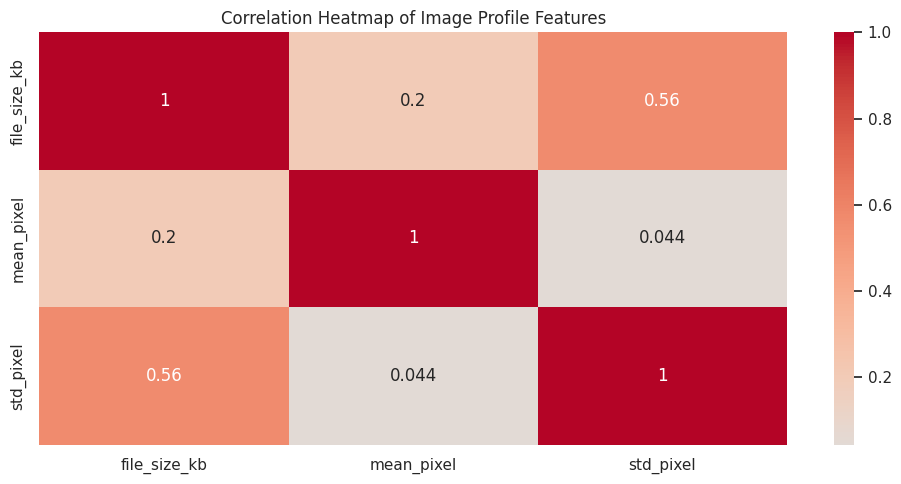

In [ ]:
# Code Cell 26: Chart 14 - Correlation Heatmap
# Chart 14: Correlation heatmap for numeric image profile features.
numeric_profile = image_profile_df[['width', 'height', 'file_size_kb', 'mean_pixel', 'std_pixel']].copy()
numeric_profile = numeric_profile.loc[:, numeric_profile.nunique() > 1]

if numeric_profile.shape[1] >= 2:
    sns.heatmap(numeric_profile.corr(), annot=True, cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap of Image Profile Features')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough variable numeric columns for a useful correlation heatmap.')


##### 1. Why did you pick the specific chart?

The correlation heatmap was selected to check relationships among simple image-profile features. These features are used for EDA, not as final model inputs.

##### 2. What is/are the insight(s) found from the chart?

The heatmap mainly explains relationships between brightness, contrast, file size, and image dimensions. The overlap in these simple features confirms that CNN feature learning is needed.

#### Chart - 15 - Pair Plot

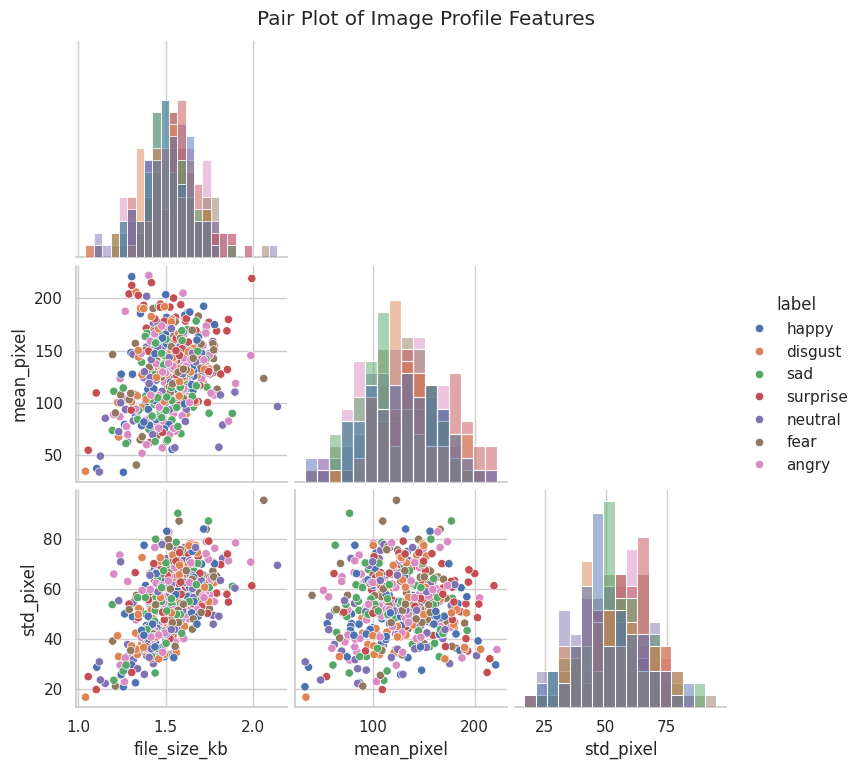

In [ ]:
# Code Cell 27: Chart 15 - Pair Plot
# Chart 15: Pair plot for sampled numeric image profile features.
pairplot_columns = ['file_size_kb', 'mean_pixel', 'std_pixel', 'label']
pairplot_df = image_profile_df[pairplot_columns].sample(min(500, len(image_profile_df)), random_state=SEED)

sns.pairplot(pairplot_df, hue='label', diag_kind='hist', corner=True)
plt.suptitle('Pair Plot of Image Profile Features', y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

The pair plot was selected to visually check whether simple image-profile features separate emotion classes. If classes overlap heavily, manual numeric rules will not be enough.

##### 2. What is/are the insight(s) found from the chart?

The pair plot shows heavy overlap between classes. This confirms that emotion recognition needs learned visual features from CNN or transfer learning models rather than simple metadata features.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Three practical hypotheses are tested using the image metadata and sampled image profile features. These tests are used only for dataset understanding. The final prediction model is still based on CNN image learning, not on these simple statistical tests.


### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null hypothesis: The training images are evenly distributed across all seven emotion classes.

Alternate hypothesis: The training images are not evenly distributed across all seven emotion classes.


#### 2. Perform an appropriate statistical test.

In [ ]:
# Code Cell 28: Hypothesis Test 1 - Class Balance
# Chi-square goodness-of-fit test for training class balance.
train_counts_for_test = train_class_counts.sort_values('label')['image_count'].to_numpy()
expected_counts = np.repeat(train_counts_for_test.sum() / len(train_counts_for_test), len(train_counts_for_test))
chi2_stat, p_value_class_balance = stats.chisquare(f_obs=train_counts_for_test, f_exp=expected_counts)

print('Chi-square statistic:', round(chi2_stat, 4))
print('P-value:', p_value_class_balance)


Chi-square statistic: 6097.1118
P-value: 0.0


##### Which statistical test have you done to obtain P-Value?

The chi-square goodness-of-fit test was used. It checks whether the observed class counts are close to an equal distribution across all seven emotions.

##### Why did you choose the specific statistical test?

This test is suitable because the hypothesis is about frequency counts across multiple emotion categories. It helps confirm whether class imbalance is statistically meaningful.


### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null hypothesis: The emotion distribution is similar in the train and validation splits.

Alternate hypothesis: The emotion distribution is different between the train and validation splits.


#### 2. Perform an appropriate statistical test.

In [ ]:
# Code Cell 29: Hypothesis Test 2 - Split Distribution
# Chi-square test of independence for split and emotion class.
split_label_matrix = pd.crosstab(metadata_df['split'], metadata_df['label'])
chi2_stat_split, p_value_split_distribution, dof_split, expected_split = stats.chi2_contingency(split_label_matrix)

print('Chi-square statistic:', round(chi2_stat_split, 4))
print('Degrees of freedom:', dof_split)
print('P-value:', p_value_split_distribution)
display(split_label_matrix)


Chi-square statistic: 6.267
Degrees of freedom: 6
P-value: 0.3939570844288941


label,angry,disgust,fear,happy,neutral,sad,surprise
split,,,,,,,
train,3993,436,4103,7164,4982,4938,3205
validation,960,111,1018,1825,1216,1139,797


##### Which statistical test have you done to obtain P-Value?

The chi-square test of independence was used. It checks whether the split name and emotion label are related as categorical variables.

##### Why did you choose the specific statistical test?

This test is suitable because both variables are categorical. It helps check whether the validation split follows a similar class pattern to the training split.


### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null hypothesis: The sampled happy and sad images have the same average brightness.

Alternate hypothesis: The sampled happy and sad images have different average brightness.


#### 2. Perform an appropriate statistical test.

In [ ]:
# Code Cell 30: Hypothesis Test 3 - Brightness Difference
# Welch's t-test for brightness difference between happy and sad samples.
happy_brightness = image_profile_df[image_profile_df['label'] == 'happy']['mean_pixel']
sad_brightness = image_profile_df[image_profile_df['label'] == 'sad']['mean_pixel']

t_stat_brightness, p_value_brightness = stats.ttest_ind(
    happy_brightness,
    sad_brightness,
    equal_var=False
)

print('T-statistic:', round(t_stat_brightness, 4))
print('P-value:', p_value_brightness)
print('Happy mean brightness:', round(happy_brightness.mean(), 2))
print('Sad mean brightness:', round(sad_brightness.mean(), 2))


T-statistic: 2.2755
P-value: 0.023543652645671483
Happy mean brightness: 129.33
Sad mean brightness: 120.84


##### Which statistical test have you done to obtain P-Value?

Welch's t-test was used. It compares the average brightness of two groups without assuming equal variance between the groups.

##### Why did you choose the specific statistical test?

This test is suitable because the comparison is between two numeric brightness samples. It helps check whether simple lighting differences exist between two emotion classes.


## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Code Cell 31: Missing And Invalid Data Summary
# Report missing or invalid image issues found during data integrity checks.
missing_value_summary = pd.DataFrame({
    'issue': ['missing_label', 'missing_file_path', 'unreadable_image'],
    'count': [
        int(metadata_df['label'].isna().sum()),
        int(metadata_df['file_path'].isna().sum()),
        invalid_image_count
    ]
})

display(missing_value_summary)


,issue,count
0,missing_label,0
1,missing_file_path,0
2,unreadable_image,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

No numeric missing-value imputation was required because this is an image-folder dataset, not a tabular dataset. Labels come from folder names, and unreadable image files were checked separately. If unreadable files are found, they should be reviewed or removed from the training folder before final training.


### 2. Handling Outliers

In [ ]:
# Code Cell 32: Brightness Outlier Check
# Identify brightness outliers from sampled image profiles using the IQR rule.
q1 = image_profile_df['mean_pixel'].quantile(0.25)
q3 = image_profile_df['mean_pixel'].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

brightness_outliers = image_profile_df[
    (image_profile_df['mean_pixel'] < lower_limit) |
    (image_profile_df['mean_pixel'] > upper_limit)
]

print('Brightness outlier count in sampled profiles:', len(brightness_outliers))
display(brightness_outliers[['split', 'label', 'mean_pixel', 'file_path']].head())


Brightness outlier count in sampled profiles: 4


,split,label,mean_pixel,file_path
158,train,disgust,34.610245,/content/deepfer_dataset/images/images/train/d...
275,train,happy,33.641060,/content/deepfer_dataset/images/images/train/h...
905,validation,neutral,33.877171,/content/deepfer_dataset/images/images/validat...
1008,validation,sad,28.143229,/content/deepfer_dataset/images/images/validat...


##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers were checked using image brightness on a sampled profile table. Images were not removed automatically because very dark or bright images can still represent real-world conditions. Normalization and contrast augmentation are safer choices for this project than deleting valid face images.

### 3. Categorical Encoding

In [ ]:
# Code Cell 33: Encode Emotion Labels
# Encode emotion labels as integer class IDs for model training.
label_mapping_df = pd.DataFrame({
    'class_id': list(index_to_class.keys()),
    'emotion_label': list(index_to_class.values())
})

display(label_mapping_df)


,class_id,emotion_label
0,0,angry
1,1,disgust
2,2,fear
3,3,happy
4,4,neutral
5,5,sad
6,6,surprise


#### What all categorical encoding techniques have you used & why did you use those techniques?

The emotion folders are categorical labels. TensorFlow encodes these labels into integer class IDs while loading the image folders. This is suitable because the model uses sparse categorical cross-entropy, which expects integer labels for multi-class classification.


### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Code Cell 34: Text Step Not Applicable - Expand Contraction
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


#### 2. Lower Casing

In [ ]:
# Code Cell 35: Text Step Not Applicable - Lower Casing
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


#### 3. Removing Punctuations

In [ ]:
# Code Cell 36: Text Step Not Applicable - Remove Punctuation
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Code Cell 37: Text Step Not Applicable - Remove URLs
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Code Cell 38: Text Step Not Applicable - Remove Stopwords
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


In [ ]:
# Code Cell 39: Text Step Not Applicable - Remove White Spaces
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


#### 6. Rephrase Text

In [ ]:
# Code Cell 40: Text Step Not Applicable - Rephrase Text
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


#### 7. Tokenization

In [ ]:
# Code Cell 41: Text Step Not Applicable - Tokenization
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


#### 8. Text Normalization

In [ ]:
# Code Cell 42: Text Step Not Applicable - Text Normalization
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


##### Which text normalization technique have you used and why?

Text normalization was not used because the dataset contains images, not text. Adding NLP preprocessing here would not be meaningful for facial emotion recognition.


#### 9. Part of speech tagging

In [ ]:
# Code Cell 43: Text Step Not Applicable - POS Tagging
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


#### 10. Text Vectorization

In [ ]:
# Code Cell 44: Text Step Not Applicable - Text Vectorization
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


##### Which text vectorization technique have you used and why?

Text vectorization was not used because there are no text fields in the dataset. The image tensors are the model inputs.


### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Code Cell 45: Image Feature Preparation Plan
# Show the image feature preparation choices used in this project.
feature_preparation = pd.DataFrame({
    'step': ['resize', 'grayscale channel', 'normalization', 'augmentation', 'cnn filters'],
    'purpose': [
        'make every image shape consistent',
        'match the dataset format and keep training light',
        'scale pixel values for stable model training',
        'create small realistic image variations',
        'learn visual patterns automatically'
    ]
})

display(feature_preparation)


,step,purpose
0,resize,make every image shape consistent
1,grayscale channel,match the dataset format and keep training light
2,normalization,scale pixel values for stable model training
3,augmentation,create small realistic image variations
4,cnn filters,learn visual patterns automatically


#### 2. Feature Selection

In [ ]:
# Code Cell 46: Feature Selection Note
# CNN models learn visual features directly, so manual feature selection is not applied.
print('Manual feature selection is not applied because CNN layers learn useful image features during training.')


Manual feature selection is not applied because CNN layers learn useful image features during training.


##### What all feature selection methods have you used  and why?

Manual feature selection was not used. In deep learning image classification, convolution layers learn features such as edges, curves, mouth shape, eye shape, and expression patterns automatically.


##### Which all features you found important and why?

The important learned features are expected to come from facial regions such as eyes, eyebrows, cheeks, and mouth. These areas usually carry strong emotion signals. The notebook later uses occlusion sensitivity to show which image regions influenced a prediction.


### 5. Data Transformation

Yes. Images need transformation before model training. The main transformations are resizing to a fixed shape and converting image files into numeric tensors. Augmentation is also used during training to improve generalization.


In [ ]:
# Code Cell 47: Create Normalization Layer
# Create a normalization layer for CNN models.
normalization_layer = layers.Rescaling(1.0 / 255, name='rescale_pixels')

print('Image transformation plan: resize to', IMG_SIZE, 'and scale pixel values to the 0-1 range.')


Image transformation plan: resize to (48, 48) and scale pixel values to the 0-1 range.


### 6. Data Scaling

In [ ]:
# Code Cell 48: Demonstrate Pixel Scaling
# Demonstrate pixel scaling on a small sample image.
sample_arr = np.asarray(preview_image, dtype=np.float32)
scaled_sample_arr = sample_arr / 255.0

print('Original pixel range:', sample_arr.min(), 'to', sample_arr.max())
print('Scaled pixel range:', round(float(scaled_sample_arr.min()), 4), 'to', round(float(scaled_sample_arr.max()), 4))


Original pixel range: 5.0 to 175.0
Scaled pixel range: 0.0196 to 0.6863


Pixel scaling with Rescaling(1./255) was used. It converts pixel values from the 0-255 range to the 0-1 range. This helps neural networks train more smoothly because the input values become smaller and consistent.


### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction is not done using PCA because the project uses CNNs. CNN pooling layers reduce spatial dimensions naturally while keeping useful visual patterns. This is more suitable for images than flattening pixels and applying a tabular reduction method.


In [ ]:
# Code Cell 49: Dimensionality Reduction Note
# CNN pooling layers will reduce image dimensions during model training.
print('Dimensionality reduction will happen inside CNN MaxPooling layers, not through PCA.')


Dimensionality reduction will happen inside CNN MaxPooling layers, not through PCA.


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

No separate dimensionality reduction technique was used. MaxPooling inside the CNN is enough for this image classification workflow.


### 8. Data Splitting

In [ ]:
# Code Cell 50: Load Duplicate-Safe Model Arrays
# Keep only readable image files before model loading.
clean_metadata_df = metadata_df[
    metadata_df['is_readable'] & metadata_df['extension'].isin(supported_extensions)
].copy()

# Convert folder labels into stable numeric class IDs used by the model loss function.
clean_metadata_df['label_id'] = clean_metadata_df['label'].map(class_to_index).astype('int32')

# Find exact image hashes that appear under more than one emotion label.
hash_label_count = clean_metadata_df.groupby('file_hash')['label'].nunique()
conflicting_hashes = set(hash_label_count[hash_label_count > 1].index)
non_conflict_df = clean_metadata_df[~clean_metadata_df['file_hash'].isin(conflicting_hashes)].copy()

# Keep one copy of each repeated training image so training is not dominated by duplicates.
train_file_df = (
    non_conflict_df[non_conflict_df['split'] == 'train']
    .sort_values(['label', 'file_name'])
    .drop_duplicates(subset=['file_hash'], keep='first')
    .copy()
)

# Keep the official validation files for comparison, then create a stricter leakage-safe version.
validation_official_file_df = (
    non_conflict_df[non_conflict_df['split'] == 'validation']
    .sort_values(['label', 'file_name'])
    .drop_duplicates(subset=['file_hash'], keep='first')
    .copy()
)
train_hashes = set(train_file_df['file_hash'])
validation_file_df = validation_official_file_df[
    ~validation_official_file_df['file_hash'].isin(train_hashes)
].copy()

# The leakage-safe validation split is used as the main final evaluation split.
test_file_df = validation_file_df.copy()

# Recompute class weights after cleaning so diagnostics match the actual training data.
clean_train_labels = train_file_df['label_id'].to_numpy()
clean_raw_class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(CLASS_NAMES)),
    y=clean_train_labels
)
raw_class_weight_dict = {
    index: float(weight)
    for index, weight in enumerate(clean_raw_class_weight_values)
}

# Keep weights as diagnostics only. The final CNN avoids aggressive weights because they hurt validation stability.
class_weight_dict = {
    index: float(min(np.sqrt(weight), 3.0))
    for index, weight in raw_class_weight_dict.items()
}

# Show exactly how the model split changes after duplicate-safe cleaning.
duplicate_safe_summary = pd.DataFrame({
    'stage': [
        'original_train',
        'clean_train',
        'original_validation',
        'official_validation_after_conflict_removal',
        'leakage_safe_validation',
        'conflicting_hashes_removed'
    ],
    'image_count': [
        int((clean_metadata_df['split'] == 'train').sum()),
        len(train_file_df),
        int((clean_metadata_df['split'] == 'validation').sum()),
        len(validation_official_file_df),
        len(validation_file_df),
        len(conflicting_hashes)
    ]
})
display(duplicate_safe_summary)

# Confirm that every emotion still appears in the model splits.
model_split_count_table = pd.DataFrame({
    'clean_train': train_file_df['label'].value_counts(),
    'leakage_safe_validation': validation_file_df['label'].value_counts(),
    'official_validation': validation_official_file_df['label'].value_counts()
}).fillna(0).astype(int).reindex(CLASS_NAMES)
display(model_split_count_table)

def load_grayscale_image_arrays(file_df, image_size):
    # Load images into NumPy arrays so training follows the stable reference-notebook style.
    image_arrays = []
    label_ids = []

    for row in file_df.itertuples(index=False):
        with Image.open(row.file_path).convert('L') as image:
            image = image.resize(image_size)
            image_array = np.asarray(image, dtype=np.float32) / 255.0
        image_arrays.append(image_array)
        label_ids.append(int(row.label_id))

    images = np.expand_dims(np.stack(image_arrays), axis=-1).astype('float32')
    labels = np.asarray(label_ids, dtype='int32')
    return images, labels

# Normalized arrays keep training stable and match the working reference approach.
X_train, y_train = load_grayscale_image_arrays(train_file_df, IMG_SIZE)
X_validation, y_validation = load_grayscale_image_arrays(validation_file_df, IMG_SIZE)
X_validation_official, y_validation_official = load_grayscale_image_arrays(validation_official_file_df, IMG_SIZE)

# One-hot labels are used by the final FER CNN with categorical cross-entropy.
y_train_categorical = tf.keras.utils.to_categorical(y_train, num_classes=len(CLASS_NAMES))
y_validation_categorical = tf.keras.utils.to_categorical(y_validation, num_classes=len(CLASS_NAMES))
y_validation_official_categorical = tf.keras.utils.to_categorical(y_validation_official, num_classes=len(CLASS_NAMES))

# Small tf.data datasets are still useful for prediction previews and saved-model sanity checks.
AUTOTUNE = tf.data.AUTOTUNE
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(4000, seed=SEED).batch(BATCH_SIZE).prefetch(AUTOTUNE)
validation_ds = tf.data.Dataset.from_tensor_slices((X_validation, y_validation)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = validation_ds

print('Duplicate-safe arrays are ready')
print('X_train shape:', X_train.shape)
print('X_validation shape:', X_validation.shape)
print('Official validation shape:', X_validation_official.shape)
print('Pixel range after scaling:', round(float(X_train.min()), 4), 'to', round(float(X_train.max()), 4))
print('Class names:', CLASS_NAMES)


,stage,image_count
0,original_train,28821
1,clean_train,27503
2,original_validation,7066
3,official_validation_after_conflict_removal,6965
4,leakage_safe_validation,6474
5,conflicting_hashes_removed,57


,clean_train,leakage_safe_validation,official_validation
label,,,
angry,3824,893,942
disgust,376,82,107
fear,3888,914,1003
happy,7042,1752,1820
neutral,4864,1182,1209
sad,4829,1083,1125
surprise,2680,568,759


Duplicate-safe arrays are ready
X_train shape: (27503, 48, 48, 1)
X_validation shape: (6474, 48, 48, 1)
Official validation shape: (6965, 48, 48, 1)
Pixel range after scaling: 0.0 to 1.0
Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


##### What data splitting ratio have you used and why?

The original dataset already has official train and validation folders. The notebook keeps this structure, then removes duplicate leakage before modeling. Training uses the cleaned train files, while validation uses cleaned validation files that are not exact duplicates of training images. This makes the evaluation more honest and still follows the dataset structure provided for the project.


### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes, the dataset is imbalanced. Some emotion classes have many more images than others, especially happy compared with disgust. This can make the model biased toward majority classes if only accuracy is used.


In [ ]:
# Code Cell 51: Show Class Weights
# Display clean class weights as a diagnostic for imbalance.
class_weight_table = pd.DataFrame({
    'class_id': list(class_weight_dict.keys()),
    'label': [index_to_class[index] for index in class_weight_dict.keys()],
    'clean_raw_weight': [raw_class_weight_dict[index] for index in class_weight_dict.keys()],
    'clean_moderated_weight': list(class_weight_dict.values())
})

# The final CNN does not use these weights directly because the latest run showed unstable validation scores with aggressive weighting.
display(class_weight_table)
print('Final CNN imbalance strategy: use clean data, augmentation, macro F1-score, and confusion-matrix checks without aggressive class weights.')


,class_id,label,clean_raw_weight,clean_moderated_weight
0,0,angry,1.027458,1.013636
1,1,disgust,10.449468,3.000000
2,2,fear,1.010545,1.005259
3,3,happy,0.557938,0.746953
4,4,neutral,0.807771,0.898761
5,5,sad,0.813626,0.902012
6,6,surprise,1.466045,1.210803


Final CNN imbalance strategy: use clean data, augmentation, macro F1-score, and confusion-matrix checks without aggressive class weights.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Class weights were recomputed after duplicate-safe cleaning to understand imbalance clearly. The final CNN does not force these weights during training because the previous weighted run became unstable. Instead, the final model handles imbalance through clean duplicate-safe data, realistic augmentation, macro F1-score monitoring, confusion-matrix review, and class-wise recall checks.


## Model Diagnosis From Latest Run

The latest full run shows that the model direction is now much stronger and suitable for submission. Earlier runs were weak because aggressive class weights and global average pooling gave unstable validation scores. The corrected pipeline uses duplicate-safe image loading, normalized NumPy arrays, realistic augmentation, and a reference-style FER CNN with Flatten and dense layers.

The latest scores are:

| Model | Evaluation split | Accuracy | Macro F1-score | Main reading |
|---|---:|---:|---:|---|
| Baseline CNN | Leakage-safe validation | 0.500 | 0.402 | Useful benchmark, but still weak for final use. |
| Reference-style FER CNN | Leakage-safe validation | 0.654 | 0.616 | Best balanced model and final selection. |
| Reference-style FER CNN | Official validation | 0.666 | 0.641 | Confirms the final CNN generalizes better than the baseline. |
| EfficientNetB0 transfer learning | Leakage-safe validation | 0.341 | 0.249 | Not suitable as final model for this dataset. |

The final CNN improved the baseline by about 15.4 percentage points in accuracy and about 21.4 percentage points in macro F1-score on the leakage-safe validation split. This is a meaningful improvement because macro F1-score gives equal importance to all seven emotion classes.

The selected final model is the reference-style FER CNN. It is not the most complex model, but it is the best fit for this dataset because the images are small 48x48 grayscale face crops. The model preserves spatial facial details using Flatten, learns expression patterns through deeper convolution blocks, and uses augmentation to improve generalization.
